# AmBe Charge Analysis

Analysis code for AmBe data

In [1]:
import h5py as h5 

import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib import colors, ticker

import numpy as np
import os, sys
import traceback
import glob
import pandas as pd

import h5flow 
plt.style.use('../../utils/dune.mplstyle')
from sklearn.cluster import DBSCAN

# Path to repo root (two directories above notebook)
light_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(light_root)

from light.PMT_analysis_utils import * 

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

### Load Datasets

In [2]:
# Load source data
df = pd.read_csv('../output/source_ambe_bin2_one_trig_32us_window_clusters_with_source.csv')

# Load no source data
df_nosource = pd.read_csv('../output/source_ambe_bin2_one_trig_32us_window_clusters.csv')

# Load source data clustered with eps=1cm, minimum_cluster_size=4
df_eps1size4 = pd.read_csv('../output/eps1_minsamples4/ambe_bin2_one_trig_32us_window_eps1size4.csv')

# Load no source data clustered with eps=1cm, minimum_cluster_size=4
df_nosource_eps1size4 = pd.read_csv('../output/eps1_minsamples4/nosource_ambe_bin2_one_trig_32us_window_eps1size4.csv')

### Normalize all data in terms of run time

In [3]:
# Calculate trigger rate of all files

def get_runtime(input_dataset, DEBUG=True):
    runtime = 0
    for file_count, ifile in enumerate(os.listdir(input_dataset)):
        # Run over 10% of the dataset
        if DEBUG and file_count >= int(len(os.listdir(input_dataset))*0.1):
            break

        this_file = os.path.join(input_dataset, ifile)
        h5_file = h5flow.data.H5FlowDataManager(this_file,'r')
        # file_duration is in units of seconds
        file_duration = max(h5_file['charge/events/data']['unix_ts'])-min(h5_file['charge/events/data']['unix_ts'])
        runtime += file_duration

    return runtime

In [4]:
# Get total duration of all files
no_source_runtime = get_runtime('/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source')
source_runtime = get_runtime('/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin2/one_trig_32us_window')

In [5]:
df_eps1size4_trig_ids = df_eps1size4['file_id'].astype(str)+ '::' + df_eps1size4['light_id'].astype(str)
df_nosource_eps1size4_trig_ids = df_nosource_eps1size4['file_id'].astype(str)+ '::' + df_nosource_eps1size4['light_id'].astype(str)

In [6]:
# Sample triggers from datasets normalized by run time
if source_runtime >= no_source_runtime:
    print('Source present data has more runtime')
    n_source = int(len(np.unique(df_eps1size4_trig_ids))*(no_source_runtime/source_runtime))
    n_nosource = len(np.unique(df_nosource_eps1size4_trig_ids))
else:
    print('No source data has more runtime')

Source present data has more runtime


### Recalibrate energy

In [7]:
def charge_to_energy_mev(charge_ke):
    return (np.asarray(charge_ke, dtype=np.float64) * 1e3 * 23.6) / 0.57523585 / 1e6

In [8]:
df_eps1size4['E'] = charge_to_energy_mev(df_eps1size4['Q'])
df_nosource_eps1size4['E'] = charge_to_energy_mev(df_nosource_eps1size4['Q'])

### Get cluster energies

In [9]:
# Source & No Source data

source_eps1size4_clusteredhits = pd.DataFrame(np.empty((0,9)), columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id'])
source_eps1size4_clusterE = []
source_eps1size4_clusterhitcount = []

nosource_eps1size4_clusteredhits = pd.DataFrame(np.empty((0,9)), columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id'])
nosource_eps1size4_clusterE = []
nosource_eps1size4_clusterhitcount = []

for i in np.unique(df_eps1size4_trig_ids)[:n_source]:
    temp_hits = df_eps1size4[(df_eps1size4_trig_ids==i) & (df_eps1size4['cluster_label']!=-1)]
    if len(temp_hits):
        source_eps1size4_clusteredhits = pd.concat([source_eps1size4_clusteredhits, temp_hits])
    for j in np.unique(temp_hits['id']):
        source_eps1size4_clusterE.append(sum(temp_hits['E'][temp_hits['id']==j]))
        source_eps1size4_clusterhitcount.append(len(temp_hits['E'][temp_hits['id']==j]))

print('1/2 Completed')

for i in np.unique(df_nosource_eps1size4_trig_ids)[:n_nosource]:
    temp_hits = df_nosource_eps1size4[(df_nosource_eps1size4_trig_ids==i) & (df_nosource_eps1size4['cluster_label']!=-1)]
    #temp_ids = df_nosource_eps1size4_randtrig['id'][(df_nosource_eps1size4_randtrig_trig_ids==i) & (df_nosource_eps1size4_randtrig['cluster_label']!=-1)]
    if len(temp_hits):
        nosource_eps1size4_clusteredhits = pd.concat([nosource_eps1size4_clusteredhits, temp_hits])
    for j in np.unique(temp_hits['id']):
        nosource_eps1size4_clusterE.append(sum(temp_hits['E'][temp_hits['id']==j]))
        nosource_eps1size4_clusterhitcount.append(len(temp_hits['E'][temp_hits['id']==j]))

print('2/2 Completed')

1/2 Completed
2/2 Completed


In [10]:
source_eps1size4_clusterE = np.array(source_eps1size4_clusterE)
source_eps1size4_clusterhitcount = np.array(source_eps1size4_clusterhitcount)
nosource_eps1size4_clusterE = np.array(nosource_eps1size4_clusterE)
nosource_eps1size4_clusterhitcount = np.array(nosource_eps1size4_clusterhitcount)

In [11]:
# TODO: save the source and no source data

In [12]:
# Load pre-processed files that contain simulation (see Inspect_Data.ipynb)

MC_df = pd.read_csv('../output/MC_AmBe_Prod_03-21_eps1size4.csv', index_col=0)
df_nosource_MC_overlay = pd.read_csv('../output/nosource_MC_overlay_04-20_eps1size4.csv', index_col=0)

In [13]:
# Generate list of trig ids for datasets that don't yet have them

nosource_MC_overlay_trig_ids = df_nosource_MC_overlay['file_id'].astype(str)+ '::' + df_nosource_MC_overlay['light_id'].astype(str)
print(len(nosource_MC_overlay_trig_ids))
# select as many triggers as the dataset with the least triggers:
MC_trig_ids = MC_df['file_id'].astype(str)+ '::' + MC_df['light_id'].astype(str)

19655


In [14]:
# Recalibrate energy
MC_df['E'] = charge_to_energy_mev(MC_df['Q'])

In [15]:
# Generate an overlay dataset based on the normalizations above
norm_arr_nosource_MC_overlay = np.empty(10)
for i in np.unique(nosource_MC_overlay_trig_ids[:n_nosource]):
    norm_arr_nosource_MC_overlay = np.vstack([norm_arr_nosource_MC_overlay, df_nosource_MC_overlay[nosource_MC_overlay_trig_ids==i]])

norm_df_nosource_MC_overlay = pd.DataFrame(norm_arr_nosource_MC_overlay[1:], columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id', 'overlay_label'])

In [16]:
# Cluster energy of overlay

nosource_MC_overlay_clustE = []

for i in np.unique(norm_df_nosource_MC_overlay['id']):
    tempsum = sum(norm_df_nosource_MC_overlay['E'][(norm_df_nosource_MC_overlay['id']==i) & (norm_df_nosource_MC_overlay['cluster_label']!=-1)].astype(float))
    if tempsum==0:
        pass
    else:
        nosource_MC_overlay_clustE.append(tempsum)

nosource_MC_overlay_clustE = np.array(nosource_MC_overlay_clustE)

In [17]:
# Get cluster energy of overlay dataset with background and overlaid events separate

nosource_MC_overlaid_clustE = []
nosource_MC_bkg_clustE = []

for i in np.unique(norm_df_nosource_MC_overlay['id']):
    tempdf = norm_df_nosource_MC_overlay[(norm_df_nosource_MC_overlay['id']==i) & (norm_df_nosource_MC_overlay['cluster_label']!=-1)]
    tempsum = sum(tempdf['E'].astype(float))
    if tempsum==0:
        pass
    elif np.unique(tempdf['overlay_label'])[0]==1:
        nosource_MC_overlaid_clustE.append(tempsum)
    elif np.unique(tempdf['overlay_label'])[0]==0:
        nosource_MC_bkg_clustE.append(tempsum)

nosource_MC_overlaid_clustE = np.array(nosource_MC_overlaid_clustE)
nosource_MC_bkg_clustE = np.array(nosource_MC_bkg_clustE)

In [18]:
# MC cluster energy

MC_clustE = []

# Generate a dataset with the same number of neutrons as number of overlapped triggers

snr = 0.1

norm_MC_arr = np.empty(9)
for i in np.unique(MC_trig_ids[:int(n_nosource*snr)]):
    norm_MC_arr = np.vstack([norm_MC_arr, MC_df[MC_trig_ids==i]])

norm_MC_df = pd.DataFrame(norm_MC_arr, columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id'])

for i in np.unique(norm_MC_df['id'].to_numpy()[1:]):
    tempsum = sum(norm_MC_df['E'][(norm_MC_df['id']==i) & (norm_MC_df['cluster_label']!=-1)].astype(float))
    if tempsum==0:
        pass
    else:
        MC_clustE.append(tempsum)

MC_clustE = np.array(MC_clustE)

### Event Display

In [19]:
# OVERLAY

# Event display of clusters at different energy range

#norm_df_nosource_MC_overlay[(norm_df_nosource_MC_overlay['file_id']==10.0) & (norm_df_nosource_MC_overlay['light_id']==1.0)]

# Select an event of interest
#df_nosource_MC_overlay_trig_id = [(i.split('::')[0], i.split('::')[1]) for i in norm_df_nosource_MC_overlay['id']]
plot_trig_id = (10.0,1.0)     # (file_id, light_id)
temp_df = norm_df_nosource_MC_overlay[(norm_df_nosource_MC_overlay['file_id'].astype(float)==plot_trig_id[0]) & (norm_df_nosource_MC_overlay['light_id'].astype(float)==plot_trig_id[1])]

for i in np.unique(temp_df['id']):
    print(f'Cluster Label: {i}; Cluster Energy: {sum(temp_df["E"][temp_df["id"]==i].astype(float))} MeV')

event_display(np.vstack([temp_df['x'].astype(float), temp_df['y'].astype(float), temp_df['z'].astype(float), temp_df['Q'].astype(float)]).T, 
              E=temp_df['E'].astype(float),
              cluster_label=temp_df['cluster_label'])

Cluster Label: 10.0::1.0::-1; Cluster Energy: 2.0792264069809243 MeV
Cluster Label: 10.0::1.0::0; Cluster Energy: 14.277087947644183 MeV
Cluster Label: 10.0::1.0::1; Cluster Energy: 9.394170612676568 MeV


In [20]:
# NO SOURCE DATA

# Event display of clusters at different energy range

# Select an event of interest
plot_trig_id = (10.0,1.0)     # (file_id, light_id)
temp_df = df_nosource_eps1size4[(df_nosource_eps1size4['file_id'].astype(float)==plot_trig_id[0]) & (df_nosource_eps1size4['light_id'].astype(float)==plot_trig_id[1])]

for i in np.unique(temp_df['id']):
    print(f'Cluster Label: {i}; Cluster Energy: {sum(temp_df["E"][temp_df["id"]==i].astype(float))} MeV')

event_display(np.vstack([temp_df['x'].astype(float), temp_df['y'].astype(float), temp_df['z'].astype(float), temp_df['Q'].astype(float)]).T, 
              E=temp_df['E'].astype(float),
              cluster_label=temp_df['cluster_label'])

Cluster Label: 10.0::1.0::-1.0; Cluster Energy: 0.362148149571127 MeV


In [21]:
# SOURCE DATA

# Event display of clusters at different energy range

# Select an event of interest
#plot_trig_id = (0.0,1252.0)     # (file_id, light_id)
plot_trig_id = (23.0,2315.0)     # (file_id, light_id)
temp_df = df_eps1size4[(df_eps1size4['file_id'].astype(float)==plot_trig_id[0]) & (df_eps1size4['light_id'].astype(float)==plot_trig_id[1])]

for i in np.unique(temp_df['id']):
    print(f'Cluster Label: {i}; Cluster Energy: {sum(temp_df["E"][temp_df["id"]==i].astype(float))} MeV')

event_display(np.vstack([temp_df['x'].astype(float), temp_df['y'].astype(float), temp_df['z'].astype(float), temp_df['Q'].astype(float)]).T, 
              E=temp_df['E'].astype(float),
              cluster_label=temp_df['cluster_label'])

Cluster Label: 23.0::2315.0::-1.0; Cluster Energy: 23.004086146622114 MeV
Cluster Label: 23.0::2315.0::0.0; Cluster Energy: 66.73389759618058 MeV
Cluster Label: 23.0::2315.0::1.0; Cluster Energy: 1.7746997483693243 MeV
Cluster Label: 23.0::2315.0::2.0; Cluster Energy: 362.9836575853936 MeV
Cluster Label: 23.0::2315.0::3.0; Cluster Energy: 9.309261988502897 MeV
Cluster Label: 23.0::2315.0::4.0; Cluster Energy: 20.47139023392828 MeV
Cluster Label: 23.0::2315.0::5.0; Cluster Energy: 3.72172342323248 MeV
Cluster Label: 23.0::2315.0::6.0; Cluster Energy: 8.366038408107242 MeV
Cluster Label: 23.0::2315.0::7.0; Cluster Energy: 47.25027481214342 MeV


### Sideband fit to detemine the SNR of the Overlay

In [22]:
from scipy.optimize import curve_fit

In [23]:
# Define histograms

bins_range = np.arange(0,10,0.5)
h_bin_centers = 0.5 * (bins_range[:-1] + bins_range[1:])

h_overlay, _ = np.histogram(nosource_MC_overlaid_clustE, bins=bins_range)
h_bkg, _ = np.histogram(nosource_MC_bkg_clustE, bins=bins_range)
h_source, _ = np.histogram(source_eps1size4_clusterE, bins=bins_range)
h_nosource, _ = np.histogram(nosource_eps1size4_clusterE, bins=bins_range)
h_MC, _ = np.histogram(MC_clustE, bins=bins_range)

# Calculate differences
source_nosource_diff = h_source - h_nosource
overlay_nosource_diff = h_overlay - h_nosource

# Calculate errors
h_source_err = np.sqrt(h_source)
h_nosource_err = np.sqrt(h_nosource)
h_MC_err = np.sqrt(h_MC)

In [24]:
# define the fit function
# Only fit to the bins in the 0-5MeV range

def overlay_by_snr(x, a, b):
    return a*h_bkg[:9]+b*h_overlay[:9]

In [25]:
# Only fit to the bins in the 0-5MeV range

pars,cov = curve_fit(overlay_by_snr, h_bin_centers[:9], h_source[:9], p0=[1, 1])

In [26]:
new_snr = 0.1*(pars[1]/pars[0])
print(pars)
print(f"SNR after performing the fit {new_snr}")

[0.95634633 0.8477577 ]
SNR after performing the fit 0.08864546985025532


In [27]:
h_fit = pars[0]*h_bkg+pars[1]*h_overlay

In [ ]:
# Calculate the difference between background and overlay
fitted_overlay_nosource_diff = h_fit - h_nosource

### Comparison Plots

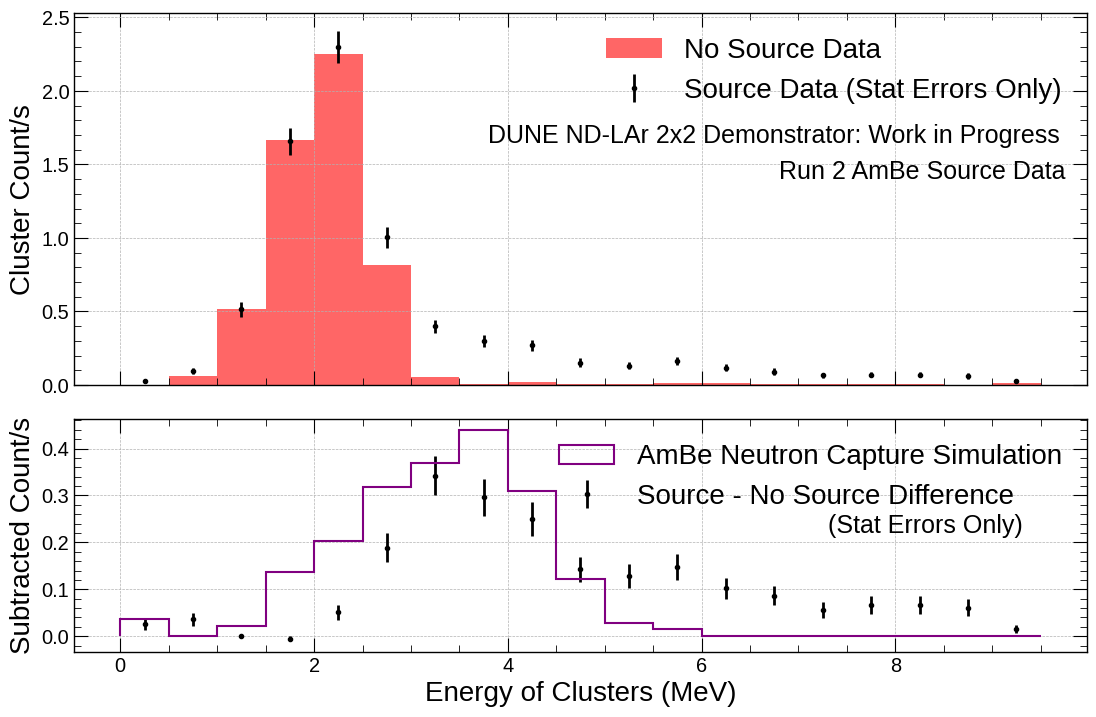

In [31]:
# Comparison plot for source-no source data

# NOTE: Normalized by runtime
runtime = no_source_runtime

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(11, 7))

f.tight_layout()

a0.errorbar((bins_range+0.5*np.diff(bins_range)[0])[:-1], h_source/runtime, yerr=h_source_err/runtime, linestyle='none', color='black',  marker='.', label='Source Data (Stat Errors Only)')

a0.hist(nosource_eps1size4_clusterE, weights=np.ones_like(nosource_eps1size4_clusterE)/runtime, linestyle='none', color='red', histtype='bar', bins=np.arange(0,10,0.5), label='No Source Data', alpha=0.6)
# Bottom plot that shows differences between datasets and simulated neutron captures
a1.errorbar((bins_range+0.5*np.diff(bins_range)[0])[:-1], source_nosource_diff/runtime, yerr=np.sqrt(np.abs(source_nosource_diff))/runtime, linestyle='none', color='black', marker='.', label='Source - No Source Difference')
a1.hist(MC_clustE, weights=np.ones(len(MC_clustE))*sum(abs(source_nosource_diff))/runtime, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation', density=True)

a1.set_xlabel('Energy of Clusters (MeV)', fontsize=20)
a1.set_ylabel('Subtracted Count/s', fontsize=20)
a0.set_ylabel('Cluster Count/s', fontsize=20)
#a0.text(7.0, 125.0, f'Overlay SNR={new_snr:.3f}')
a0.text(3.8, 1.65, 'DUNE ND-LAr 2x2 Demonstrator: Work in Progress', fontsize=18)
a0.text(6.8, 1.4, 'Run 2 AmBe Source Data', fontsize=18)
a1.text(7.3, 0.22, '(Stat Errors Only)', fontsize=18)
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
#a0.set_ylim((0,550))
a0.legend(fontsize=20)
a1.legend(fontsize=20)
plt.show()

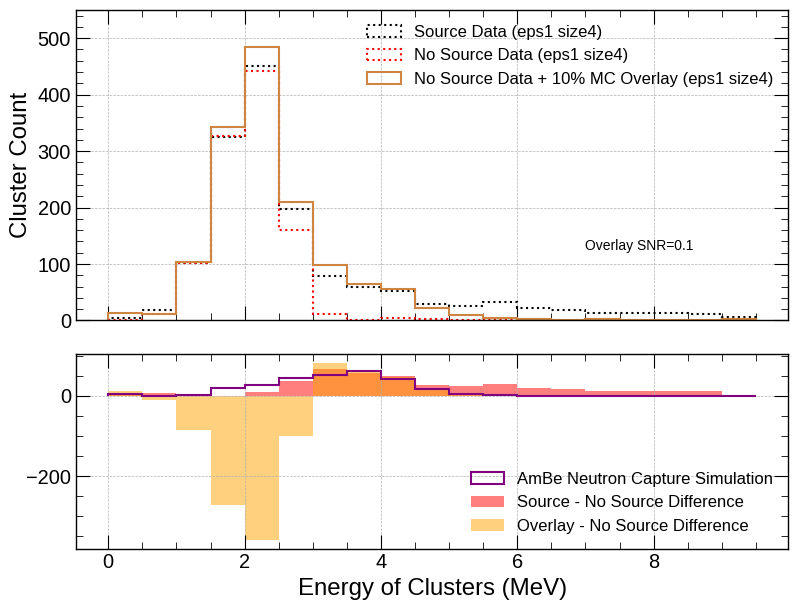

In [29]:
# Visualize the overlayed results along with the source-no source difference

# Cluster energy

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(8, 6))

f.tight_layout()

a0.hist(source_eps1size4_clusterE, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.5), label='Source Data (eps1 size4)')
a0.hist(nosource_eps1size4_clusterE, linestyle=':', color='red', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data (eps1 size4)')
a0.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data + 10% MC Overlay (eps1 size4)')

# Bottom plot that shows differences between datasets and simulated neutron captures
a1.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='red', alpha=0.5, label='Source - No Source Difference')
a1.bar(bins_range[:-1], overlay_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='orange', alpha=0.5, label='Overlay - No Source Difference')
a1.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation')

a1.set_xlabel('Energy of Clusters (MeV)')
a0.set_ylabel('Cluster Count')
a0.text(7.0, 125.0, 'Overlay SNR=0.1')
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
a0.set_ylim((0,550))
a0.legend()
a1.legend()
plt.show()

Clearly need more tuning for this to make sense. Work in progress.

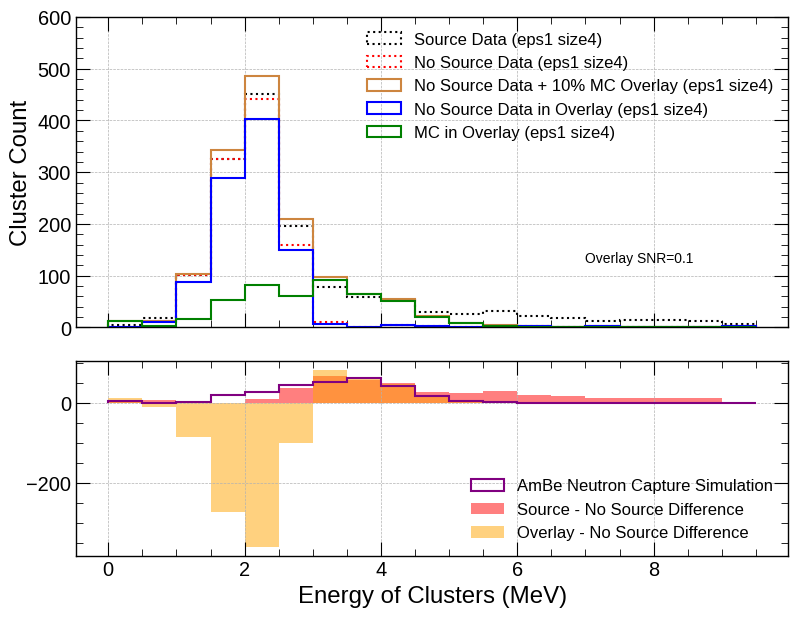

In [30]:
# Visualize the overlayed results along with the source-no source difference and the overlaid + bkg

# Cluster energy

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(8, 6))

f.tight_layout()

a0.hist(source_eps1size4_clusterE, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.5), label='Source Data (eps1 size4)')
a0.hist(nosource_eps1size4_clusterE, linestyle=':', color='red', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data (eps1 size4)')
a0.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data + 10% MC Overlay (eps1 size4)')
a0.hist(nosource_MC_bkg_clustE, color='blue', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data in Overlay (eps1 size4)')
a0.hist(nosource_MC_overlaid_clustE, color='green', histtype='step', bins=np.arange(0,10,0.5), label='MC in Overlay (eps1 size4)')

# Bottom plot that shows differences between datasets and simulated neutron captures
a1.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='red', alpha=0.5, label='Source - No Source Difference')
a1.bar(bins_range[:-1], overlay_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='orange', alpha=0.5, label='Overlay - No Source Difference')
a1.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation')

a1.set_xlabel('Energy of Clusters (MeV)')
a0.set_ylabel('Cluster Count')
a0.text(7.0, 125.0, 'Overlay SNR=0.1')
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
a0.set_ylim((0,600))
a0.legend()
a1.legend()
plt.show()

#### Additional Cluster Size Cut

In [32]:
# The cut
min_clust_size = 6

In [33]:
source_clustE_selected = source_eps1size4_clusterE[source_eps1size4_clusterhitcount>=min_clust_size]
nosource_clustE_selected = nosource_eps1size4_clusterE[nosource_eps1size4_clusterhitcount>=min_clust_size]

# Reformat the source and no source histograms and calculate the uncertainty of each bin

source_clustE_selected_hist, _ = np.histogram(source_clustE_selected, bins=bins_range)
nosource_clustE_selected_hist, _ = np.histogram(nosource_clustE_selected, bins=bins_range)

source_clustE_selected_hist_err = np.sqrt(source_clustE_selected_hist)
nosource_clustE_selected_hist_err = np.sqrt(nosource_clustE_selected_hist)

source_nosource_diff_selected = source_clustE_selected_hist - nosource_clustE_selected_hist

In [34]:
# Export the histograms after selection cuts
np.savetxt('../output/cluster_energy/source_nosource_diff_selected.csv', source_nosource_diff_selected, delimiter=',')
np.savetxt('../output/cluster_energy/MC_clustE.csv', MC_clustE, delimiter=',')

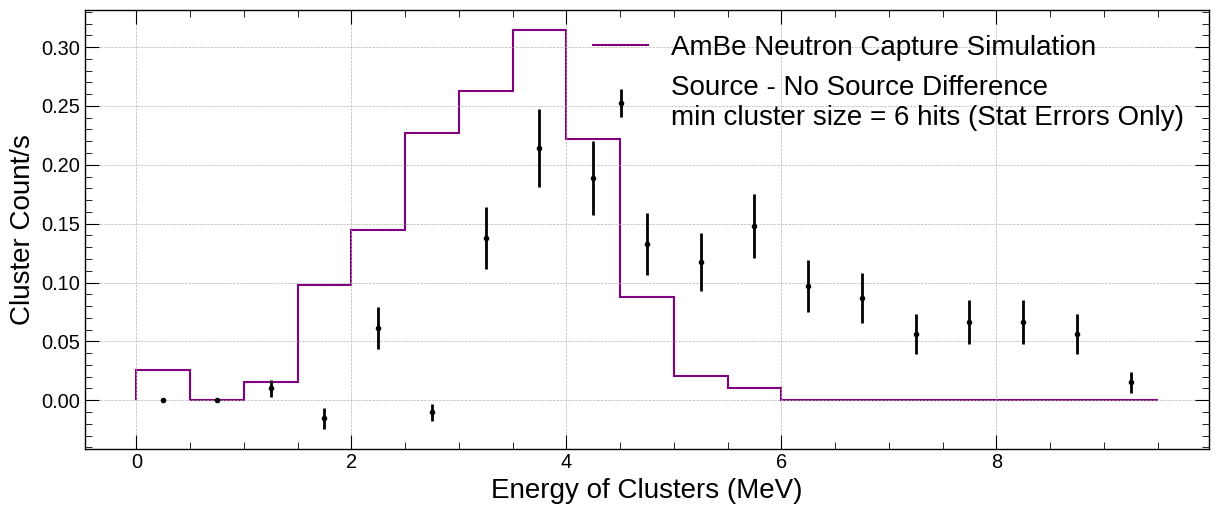

In [35]:
runtime = no_source_runtime

f, a1 = plt.subplots(figsize=(12, 5))
f.tight_layout()

# Data histogram represented by error bars
bin_centers = (bins_range + 0.5*np.diff(bins_range)[0])[:-1]
bin_widths = np.diff(bins_range)

data_counts = source_nosource_diff_selected / runtime
data_errors = np.sqrt(np.abs(source_nosource_diff_selected)) / runtime

a1.errorbar(
    bin_centers,
    data_counts,
    yerr=data_errors,
    linestyle='none',
    color='black',
    marker='.',
    label='Source - No Source Difference\nmin cluster size = 6 hits (Stat Errors Only)'
)

# MC histogram
mc_bins = np.arange(0, 10, 0.5)
mc_counts, mc_edges = np.histogram(MC_clustE, bins=mc_bins)

# Area under the data histogram
data_area = np.sum(data_counts * bin_widths)

# Area under the raw MC histogram
mc_bin_widths = np.diff(mc_edges)
mc_area = np.sum(mc_counts * mc_bin_widths)

# Scale MC to match the data histogram area
scale_factor = data_area / mc_area

a1.stairs(
    mc_counts * scale_factor,
    mc_edges,
    color='purple',
    label='AmBe Neutron Capture Simulation'
)

a1.set_xlabel('Energy of Clusters (MeV)', fontsize=20)
a1.set_ylabel('Cluster Count/s', fontsize=20)

a1.grid(True)
a1.legend(fontsize=20)

plt.show()

### Fiducial Volume Cut

In [36]:
# Rough FV cut, not cutting entire clusters yet

def FV_Cut(df_in):

    # Conduct a fiducial volume cut for source present data that divides the TPC into top and bottom half

    df_top = df_in[df_in['y']>0]
    E_clust_top = []

    for i in np.unique(df_top['id'])[:n_source]:
        tempsum = sum(df_top['E'][(df_top['id']==i) & (df_top['cluster_label']!=-1)].astype(float))
        if tempsum==0:
            pass
        else:
            E_clust_top.append(tempsum)

    E_clust_top = np.array(E_clust_top)

    df_bottom = df_in[df_in['y']<=0]
    E_clust_bottom = []

    for i in np.unique(df_bottom['id'])[:n_source]:
        tempsum = sum(df_bottom['E'][(df_bottom['id']==i) & (df_bottom['cluster_label']!=-1)].astype(float))
        if tempsum==0:
            pass
        else:
            E_clust_bottom.append(tempsum)

    E_clust_bottom = np.array(E_clust_bottom)

    return df_top, E_clust_top, df_bottom, E_clust_bottom

In [37]:
# Make the same comparisons as above but look at the top and bottom halves of the TPCs separately

df_data_top, E_data_clust_top, df_data_bottom, E_data_clust_bottom = FV_Cut(df_eps1size4)
df_nosource_top, E_nosource_clust_top, df_nosource_bottom, E_nosource_clust_bottom = FV_Cut(df_nosource_eps1size4)

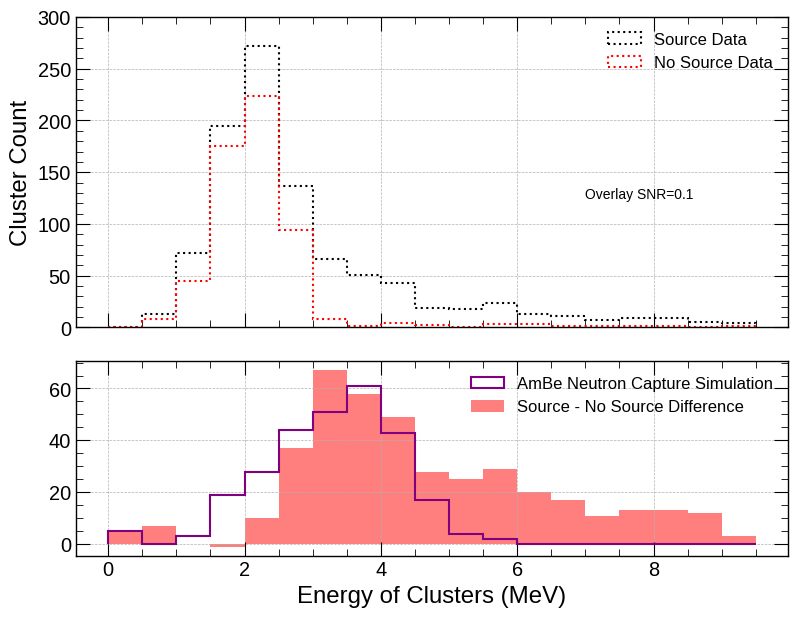

In [38]:
# Top half if all TPCs

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(8, 6))

f.tight_layout()

a0.hist(E_data_clust_top, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.5), label='Source Data')
a0.hist(E_nosource_clust_top, linestyle=':', color='red', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data')
#a0.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data + 10% MC Overlay')
#a0.step(h_bin_centers, h_fit, where='mid', label='Fit Result', color='blue', linewidth=1.5)

# Bottom plot that shows differences between datasets and simulated neutron captures
a1.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='red', alpha=0.5, label='Source - No Source Difference')
#a1.bar(bins_range[:-1], overlay_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='orange', alpha=0.5, label='Overlay - No Source Difference')
a1.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation')

a1.set_xlabel('Energy of Clusters (MeV)')
a0.set_ylabel('Cluster Count')
a0.text(7.0, 125.0, 'Overlay SNR=0.1')
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
a0.set_ylim((0,300))
a0.legend()
a1.legend()
plt.show()

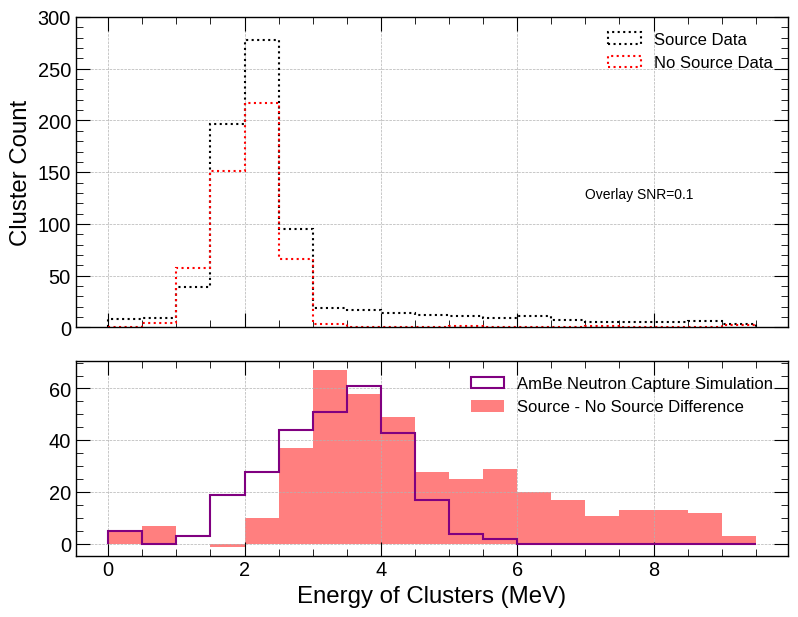

In [39]:
# Bottom half of all TPCs

f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [8, 5]}, sharex=True, figsize=(8, 6))

f.tight_layout()

a0.hist(E_data_clust_bottom, linestyle=':', color='black', histtype='step', bins=np.arange(0,10,0.5), label='Source Data')
a0.hist(E_nosource_clust_bottom, linestyle=':', color='red', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data')
#a0.hist(nosource_MC_overlay_clustE, color='peru', histtype='step', bins=np.arange(0,10,0.5), label='No Source Data + 10% MC Overlay')
#a0.step(h_bin_centers, h_fit, where='mid', label='Fit Result', color='blue', linewidth=1.5)

# Bottom plot that shows differences between datasets and simulated neutron captures
a1.bar(bins_range[:-1], source_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='red', alpha=0.5, label='Source - No Source Difference')
#a1.bar(bins_range[:-1], overlay_nosource_diff, width=np.diff(bins_range), align='edge', facecolor='orange', alpha=0.5, label='Overlay - No Source Difference')
a1.hist(MC_clustE, color='purple', histtype='step', bins=np.arange(0,10,0.5), label='AmBe Neutron Capture Simulation')

a1.set_xlabel('Energy of Clusters (MeV)')
a0.set_ylabel('Cluster Count')
a0.text(7.0, 125.0, 'Overlay SNR=0.1')
a0.grid(True)
a1.grid(True)
#plt.yscale('log')
a0.set_ylim((0,300))
a0.legend()
a1.legend()
plt.show()